# Multiclass Approach

Link to the used dataset: https://www.kaggle.com/datasets/tombackert/brain-tumor-mri-data

In [1]:
from utils import *
from models import *

In [2]:
# Create a DataFrame with image paths and labels
df = create_image_df(r"C:\Users\User\Desktop\Stat learning HW\Project\archive (6)\brain-tumor-mri-dataset")


In [3]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

In [4]:
from torchvision import transforms
from sklearn.model_selection import train_test_split

image_size = 256

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# Stratified train+val / test split
train_val_df, test_df = train_test_split(
    df, test_size=0.30, stratify=df['label_encoded'], random_state=42
)

# Split train+val in train/val
train_df, val_df = train_test_split(
    train_val_df, train_size=0.80, stratify=train_val_df['label_encoded'], random_state=42
)

# Split test in calibration/test
calibration_df, final_test_df = train_test_split(
    test_df, test_size=0.55, stratify=test_df['label_encoded'], random_state=42
)

from torch.utils.data import DataLoader

batch_size = 128

train_dataset = TumorImageDataset(train_df, transform=transform)
val_dataset = TumorImageDataset(val_df, transform=transform)
calibration_dataset = TumorImageDataset(calibration_df, transform=transform)
test_dataset = TumorImageDataset(final_test_df, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
calibration_loader = DataLoader(calibration_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)


print(f"Train: {len(train_dataset)}")
print(f"Validation: {len(val_dataset)}")
print(f"Calibration: {len(calibration_dataset)}")
print(f"Test: {len(test_dataset)}")



Train: 4005
Validation: 1002
Calibration: 965
Test: 1181


# Autoencoder

In [5]:
import torch
from torch.utils.data import Subset

# Set the device to GPU if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate the autoencoder model and move it to the device
model = Autoencoder(latent_dim=128).to(device)

# Define the loss function (Mean Squared Error for reconstruction)
criterion = nn.MSELoss()

# Use Adam optimizer for training the autoencoder
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Create DataLoader from the full training dataset
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

# -----------------------------
# Create a random subset of the training dataset

# Number of images to use for training (subset size)
sample_size = 2500

# Total number of samples in the full dataset
total_size = len(train_dataset)

# Randomly select 'sample_size' indices from the dataset
indices = torch.randperm(total_size)[:sample_size]

# Create a subset dataset using the selected indices
train_subset_2000 = Subset(train_dataset, indices)

# Create a DataLoader for the subset
train_loader_2000 = DataLoader(train_subset_2000, batch_size=256, shuffle=True)


In [ ]:
num_epochs = 100  
patience = 5       # number of epochs to wait before triggering early stopping
min_delta = 0.001   # minimum threshold for improvement
best_loss = float('inf')
trigger_times = 0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for images, _ in train_loader_2000:
        images = images.to(device)
        outputs = model(images)
        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

    # Early stopping check
    if best_loss - epoch_loss > min_delta:
        best_loss = epoch_loss
        trigger_times = 0  
    else:
        trigger_times += 1
        print(f"🔁 Nessun miglioramento significativo ({trigger_times}/{patience})")

        if trigger_times >= patience:
            print("🛑 Early stopping attivato!")
            break



Epoch [1/100], Loss: 0.2036
Epoch [2/100], Loss: 0.1061
Epoch [3/100], Loss: 0.0704
Epoch [4/100], Loss: 0.0556
Epoch [5/100], Loss: 0.0471
Epoch [6/100], Loss: 0.0417
Epoch [7/100], Loss: 0.0380
Epoch [8/100], Loss: 0.0351
Epoch [9/100], Loss: 0.0335
Epoch [10/100], Loss: 0.0323
Epoch [11/100], Loss: 0.0315
🔁 Nessun miglioramento significativo (1/5)
Epoch [12/100], Loss: 0.0310
Epoch [13/100], Loss: 0.0306
🔁 Nessun miglioramento significativo (1/5)
Epoch [14/100], Loss: 0.0302
🔁 Nessun miglioramento significativo (2/5)
Epoch [15/100], Loss: 0.0297
Epoch [16/100], Loss: 0.0293
🔁 Nessun miglioramento significativo (1/5)
Epoch [17/100], Loss: 0.0289
🔁 Nessun miglioramento significativo (2/5)
Epoch [18/100], Loss: 0.0285
Epoch [19/100], Loss: 0.0280
🔁 Nessun miglioramento significativo (1/5)
Epoch [20/100], Loss: 0.0276
🔁 Nessun miglioramento significativo (2/5)
Epoch [21/100], Loss: 0.0272
Epoch [22/100], Loss: 0.0269
🔁 Nessun miglioramento significativo (1/5)
Epoch [23/100], Loss: 0.026

In [25]:
torch.save(model.state_dict(), "autoencoder_multi.pth")


In [7]:
# Ricrea l'istanza del modello
auto_multi = Autoencoder(latent_dim=128)
auto_multi.load_state_dict(torch.load("Models/autoencoder_multi.pth"))
auto_multi.eval()  


Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Flatten(start_dim=1, end_dim=-1)
    (10): Linear(in_features=131072, out_features=128, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=128, out_features=131072, bias=True)
    (1): ReLU()
    (2): Unflatten(dim=1, unflattened_size=(128, 32, 32))
    (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tru

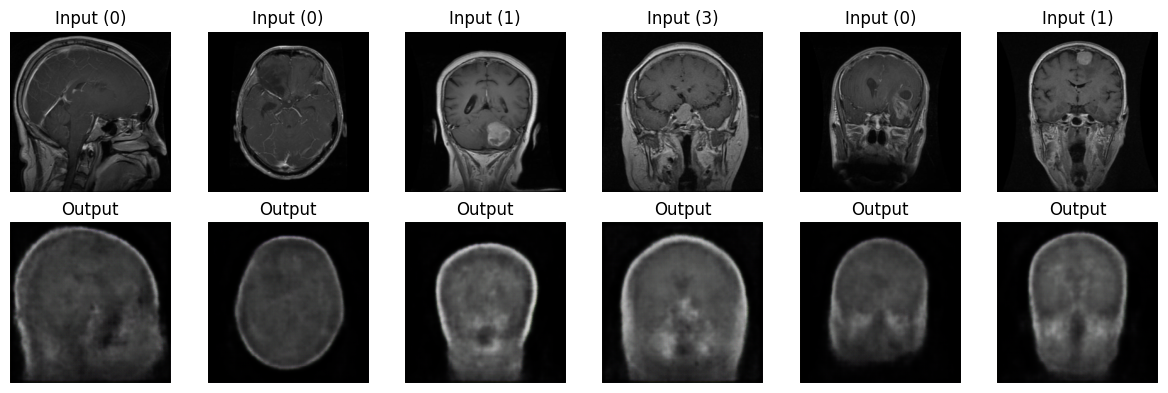

In [8]:
import matplotlib.pyplot as plt

# Set the model to evaluation mode
auto_multi.eval()

# Disable gradient computation for inference
with torch.no_grad():
    # Get a single batch from the test loader
    images, labels = next(iter(test_loader))
    images = images.to(device)

    # Pass the images through the autoencoder to get reconstructions
    outputs = auto_multi(images)

    # De-normalize from [-1, 1] to [0, 1] for visualization
    inputs = images * 0.5 + 0.5
    recons = outputs * 0.5 + 0.5

    # Display original and reconstructed images
    fig, axes = plt.subplots(2, 6, figsize=(12, 4))  # 2 rows: input/reconstruction, 6 samples
    for i in range(6):
        # Permute from [C, H, W] to [H, W, C] for matplotlib display
        axes[0, i].imshow(inputs[i].cpu().permute(1, 2, 0).numpy())
        axes[0, i].set_title(f"Input ({labels[i].item()})")
        axes[0, i].axis("off")

        axes[1, i].imshow(recons[i].cpu().permute(1, 2, 0).numpy())
        axes[1, i].set_title("Output")
        axes[1, i].axis("off")

    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()


# First Classification model

In [ ]:
encoder = auto_multi.encoder

# Create the classifier model
classifier_model = TumorMultiClassifier(encoder, latent_dim=128).to(device)

In [ ]:
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torch import nn, optim

# Set device to GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(classifier_model.parameters(), lr=1e-4, weight_decay=1e-4)

# Training configuration
num_epochs = 50
patience = 5  # For early stopping
best_val_loss = float('inf')  # Initialize best validation loss to infinity
epochs_no_improve = 0  # Counter for early stopping
best_model_state = None  # To store the best model weights

# ----------------------
# Training loop
for epoch in range(num_epochs):
    classifier_model.train()
    train_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device).long()

        outputs = classifier_model(images)  # Forward pass
        loss = criterion(outputs, labels)  # Compute loss

        optimizer.zero_grad()  # Clear previous gradients
        loss.backward()        # Backpropagation
        optimizer.step()       # Update weights

        train_loss += loss.item() * images.size(0)  # Accumulate loss

    avg_train_loss = train_loss / len(train_loader.dataset)

    # ----------------------
    # Validation phase
    classifier_model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device).long()

            outputs = classifier_model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)  # Get predicted class
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0, average='macro')
    rec = recall_score(all_labels, all_preds, zero_division=0, average='macro')
    f1 = f1_score(all_labels, all_preds, zero_division=0, average='macro')

    # Print training and validation metrics
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"Val Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")

    # ----------------------
    # Early stopping logic
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = classifier_model.state_dict()  # Save best model weights
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"\n⏹️ Early stopping at epoch {epoch+1} (no improvement in val loss for {patience} epochs)")
            break

# ----------------------
# Load best model weights (if any)
if best_model_state is not None:
    classifier_model.load_state_dict(best_model_state)

# ----------------------
# Final evaluation on the test set
classifier_model.eval()
test_preds = []
test_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device).long()

        outputs = classifier_model(images)
        preds = torch.argmax(outputs, dim=1)
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

# Compute test metrics
test_acc = accuracy_score(test_labels, test_preds)
test_prec = precision_score(test_labels, test_preds, zero_division=0, average='macro')
test_rec = recall_score(test_labels, test_preds, zero_division=0, average='macro')
test_f1 = f1_score(test_labels, test_preds, zero_division=0, average='macro')

# Print test results
print("\n📊 TEST SET PERFORMANCE")
print(f"Accuracy: {test_acc:.4f} | Precision: {test_prec:.4f} | Recall: {test_rec:.4f} | F1 Score: {test_f1:.4f}")


Epoch [1/50]
Train Loss: 1.1905 | Val Loss: 1.0123
Val Acc: 0.7944 | Prec: 0.8030 | Rec: 0.7922 | F1: 0.7806
Epoch [2/50]
Train Loss: 0.6884 | Val Loss: 0.5298
Val Acc: 0.8423 | Prec: 0.8517 | Rec: 0.8432 | F1: 0.8355
Epoch [3/50]
Train Loss: 0.3459 | Val Loss: 0.3228
Val Acc: 0.8952 | Prec: 0.8933 | Rec: 0.8946 | F1: 0.8917
Epoch [4/50]
Train Loss: 0.1603 | Val Loss: 0.2700
Val Acc: 0.9132 | Prec: 0.9112 | Rec: 0.9129 | F1: 0.9105
Epoch [5/50]
Train Loss: 0.0889 | Val Loss: 0.2727
Val Acc: 0.9072 | Prec: 0.9050 | Rec: 0.9065 | F1: 0.9040
Epoch [6/50]
Train Loss: 0.0525 | Val Loss: 0.2761
Val Acc: 0.9202 | Prec: 0.9181 | Rec: 0.9195 | F1: 0.9182
Epoch [7/50]
Train Loss: 0.0317 | Val Loss: 0.2836
Val Acc: 0.9212 | Prec: 0.9196 | Rec: 0.9209 | F1: 0.9196
Epoch [8/50]
Train Loss: 0.0244 | Val Loss: 0.2870
Val Acc: 0.9261 | Prec: 0.9245 | Rec: 0.9253 | F1: 0.9244
Epoch [9/50]
Train Loss: 0.0168 | Val Loss: 0.2948
Val Acc: 0.9291 | Prec: 0.9271 | Rec: 0.9283 | F1: 0.9275

⏹️ Early stopping 

In [36]:
torch.save(classifier_model.state_dict(), "classifier_multi_model.pth")


In [ ]:
classifier_multi_model = TumorMultiClassifier(encoder, latent_dim=128).to(device)
classifier_multi_model.load_state_dict(torch.load("Models/classifier_multi_model.pth"))
classifier_multi_model.eval()  


TumorMultiClassifier(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Flatten(start_dim=1, end_dim=-1)
    (10): Linear(in_features=131072, out_features=128, bias=True)
  )
  (input_layer): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (res_blocks): Sequential(
    (0): ResidualBlock(
      (block): Sequential(
        (0): Linear(

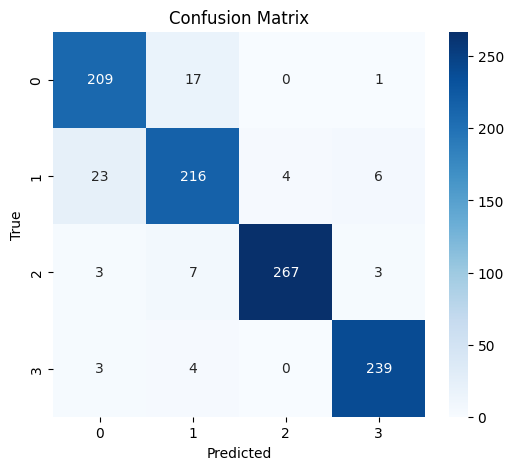

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# get predictions and true labels from validation or test set
cm = confusion_matrix(all_labels, all_preds)
labels = list(range(4))

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [45]:
from sklearn.metrics import classification_report
print(classification_report(all_labels, all_preds, zero_division=0))


              precision    recall  f1-score   support

           0       0.88      0.92      0.90       227
           1       0.89      0.87      0.88       249
           2       0.99      0.95      0.97       280
           3       0.96      0.97      0.97       246

    accuracy                           0.93      1002
   macro avg       0.93      0.93      0.93      1002
weighted avg       0.93      0.93      0.93      1002



### Multi-Class Classification Results – Tumor Detection

The model was trained using a CNN-based classifier on top of a frozen encoder to distinguish between four classes, where **class 2 represents non-tumor samples**, and the other classes correspond to different tumor types.

#### **Performance Summary**:
- **Overall Accuracy**: **93%**, indicating strong general performance across all classes.
- **Class 2 (Non-Tumor)** achieved the **highest precision (0.99)** and very high recall (0.95), showing the model is extremely confident and rarely misclassifies non-tumor images.
- **Classes 0, 1, and 3** (tumor types) also demonstrate high performance, with **F1-scores ranging from 0.88 to 0.97**, reflecting reliable detection across different tumor categories.

#### **Additional Insights**:
- The **macro average F1-score (0.93)** confirms that performance is balanced across all classes.
- The **high precision for class 2** suggests the model is conservative when predicting a sample as non-tumor — a desirable property in a medical context to avoid false negatives (i.e., missing a tumor).
- Minor misclassifications in tumor classes may be due to subtle inter-class visual similarities, which could be further reduced with more diverse training data or targeted fine-tuning.

Overall, the encoder-CNN architecture appears to effectively capture discriminative features for this 4-class tumor classification task, showing both accuracy and robustness.
